# 📊 Notebook 5: ANOVA & Case Study Analisis Komprehensif

**Topik:** ANOVA (Analysis of Variance), Studi Kasus End-to-End Data Analysis

Notebook ini merupakan **rangkuman eksperimen akhir** yang mengintegrasikan semua konsep dari Notebook 1–4.

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Load kedua dataset
df_auto = pd.read_csv('automobile_sim.csv')
df_epl  = pd.read_csv('epl_goalscorer_2021.csv')

print(f'✅ Dataset Automobile : {df_auto.shape}')
print(f'✅ Dataset EPL        : {df_epl.shape}')

✅ Dataset Automobile : (200, 10)
✅ Dataset EPL        : (50, 11)


---
## 1. ANOVA — Analysis of Variance

**Definisi:** Metode statistik untuk menguji apakah rata-rata dari dua atau lebih kelompok secara signifikan berbeda.

**Output ANOVA:**
- **F-Score** → semakin besar = perbedaan antar grup semakin besar
- **P-Value** → semakin kecil = perbedaan semakin signifikan secara statistik

Sesuai materi: `stats.f_oneway(group1, group2, group3, ...)`

In [2]:
# === ANOVA 1: Apakah drive-wheels memengaruhi harga? (dari materi) ===
df_gptest = df_auto[['drive-wheels', 'price']]
grouped_test2 = df_gptest.groupby(['drive-wheels'])

# Lihat data per kelompok
print('=== Data Price per Drive-Wheels (5 baris pertama tiap grup) ===')
for name, group in grouped_test2:
    print(f'\n[ {name} ] — {len(group)} kendaraan')
    print(group['price'].describe().to_string())

=== Data Price per Drive-Wheels (5 baris pertama tiap grup) ===

[ ('4wd',) ] — 18 kendaraan
count       18.000000
mean     23452.833333
std       7133.609879
min      12324.000000
25%      17945.500000
50%      23480.000000
75%      29053.000000
max      34215.000000

[ ('fwd',) ] — 117 kendaraan
count      117.000000
mean     21523.641026
std       7028.956135
min       7978.000000
25%      16067.000000
50%      21354.000000
75%      26433.000000
max      37982.000000

[ ('rwd',) ] — 65 kendaraan
count       65.000000
mean     22114.830769
std       6185.672888
min       7711.000000
25%      18050.000000
50%      21170.000000
75%      26751.000000
max      34356.000000


In [3]:
# Hitung ANOVA
fwd_price = grouped_test2.get_group('fwd')['price']
rwd_price = grouped_test2.get_group('rwd')['price']
awd_price = grouped_test2.get_group('4wd')['price']

f_val, p_val = stats.f_oneway(fwd_price, rwd_price, awd_price)

print('=== ANOVA: Drive-Wheels vs Price ===')
print(f'F-Score : {f_val:.4f}')
print(f'P-Value : {p_val:.4e}')
print()
if f_val > 10 and p_val < 0.001:
    print('✅ KESIMPULAN: F besar dan P sangat kecil → drive-wheels SANGAT BERPENGARUH terhadap harga')
elif p_val < 0.05:
    print('✅ KESIMPULAN: P < 0.05 → ada perbedaan signifikan antar kategori drive-wheels')
else:
    print('❌ KESIMPULAN: P > 0.05 → tidak ada perbedaan signifikan')

=== ANOVA: Drive-Wheels vs Price ===
F-Score : 0.6856
P-Value : 5.0501e-01

❌ KESIMPULAN: P > 0.05 → tidak ada perbedaan signifikan


/tmp/ipykernel_187138/1958586438.py:2: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  fwd_price = grouped_test2.get_group('fwd')['price']
/tmp/ipykernel_187138/1958586438.py:3: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  rwd_price = grouped_test2.get_group('rwd')['price']
/tmp/ipykernel_187138/1958586438.py:4: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  awd_price = grouped_test2.get_group('4wd')['price']


/tmp/ipykernel_187138/1243052534.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='drive-wheels', y='price', data=df_auto,
/tmp/ipykernel_187138/1243052534.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='drive-wheels', y='price', data=df_auto,


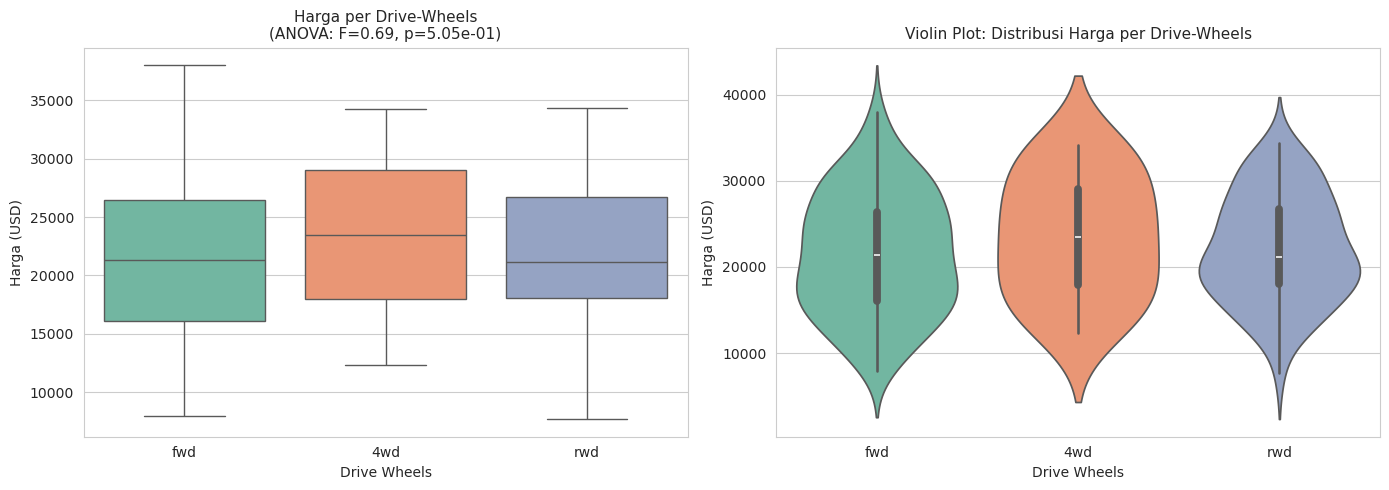

In [4]:
# Visualisasi ANOVA dengan Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='drive-wheels', y='price', data=df_auto,
            order=['fwd','4wd','rwd'], palette='Set2', ax=axes[0])
axes[0].set_title(f'Harga per Drive-Wheels\n(ANOVA: F={f_val:.2f}, p={p_val:.2e})', fontsize=11)
axes[0].set_xlabel('Drive Wheels')
axes[0].set_ylabel('Harga (USD)')

# Violin plot (lebih informatif)
sns.violinplot(x='drive-wheels', y='price', data=df_auto,
               order=['fwd','4wd','rwd'], palette='Set2', ax=axes[1])
axes[1].set_title('Violin Plot: Distribusi Harga per Drive-Wheels', fontsize=11)
axes[1].set_xlabel('Drive Wheels')
axes[1].set_ylabel('Harga (USD)')

plt.tight_layout()
plt.savefig('plot_anova_drive_wheels.png', bbox_inches='tight')
plt.show()

In [5]:
# === ANOVA 2: Apakah body-style memengaruhi harga? ===
grouped_bs = df_auto[['body-style','price']].groupby('body-style')
groups = [grouped_bs.get_group(bs)['price'] for bs in df_auto['body-style'].unique()]

f_bs, p_bs = stats.f_oneway(*groups)
print('=== ANOVA: Body-Style vs Price ===')
print(f'F-Score : {f_bs:.4f}')
print(f'P-Value : {p_bs:.4e}')
print()
if p_bs < 0.05:
    print('✅ Body-style BERPENGARUH signifikan terhadap harga (p < 0.05)')
else:
    print('❌ Body-style TIDAK berpengaruh signifikan terhadap harga')

=== ANOVA: Body-Style vs Price ===
F-Score : 1.3796
P-Value : 2.4243e-01

❌ Body-style TIDAK berpengaruh signifikan terhadap harga


In [6]:
# === ANOVA 3: EPL — Apakah tim memengaruhi jumlah gol? ===
grouped_team = df_epl.groupby('team_title')['goals']
groups_goals = [g for _, g in grouped_team if len(g) > 1]

f_team, p_team = stats.f_oneway(*groups_goals)
print('=== ANOVA: Tim vs Jumlah Gol (EPL) ===')
print(f'F-Score : {f_team:.4f}')
print(f'P-Value : {p_team:.4e}')
print()
if p_team < 0.05:
    print('✅ Tim BERPENGARUH signifikan terhadap jumlah gol pemainnya')
else:
    print('❌ Tim TIDAK berpengaruh signifikan terhadap jumlah gol')

=== ANOVA: Tim vs Jumlah Gol (EPL) ===
F-Score : 1.3500
P-Value : 2.3254e-01

❌ Tim TIDAK berpengaruh signifikan terhadap jumlah gol


---
## 2. CASE STUDY — End-to-End Analysis: EPL 2020-21

Mengintegrasikan semua teknik dari Notebook 1–5 dalam satu studi kasus terpadu.

In [7]:
# === STEP 1: Load & Overview ===
df = df_epl.copy()
print('='*50)
print('STEP 1: Overview Dataset')
print('='*50)
print(f'Shape       : {df.shape}')
print(f'Kolom       : {list(df.columns)}')
print(f'Missing val : {df.isnull().sum().sum()}')
print()
df.head()

STEP 1: Overview Dataset
Shape       : (50, 11)
Kolom       : ['player_name', 'team_title', 'position', 'games', 'goals', 'assists', 'shots', 'xG', 'yellow_cards', 'red_cards', 'key_passes']
Missing val : 0



,player_name,team_title,position,games,goals,assists,shots,xG,yellow_cards,red_cards,key_passes
0,Harry Kane,Tottenham,F,35,23,14,138,22.17,6,0,67
1,Mohamed Salah,Liverpool,F,37,22,5,76,20.25,3,1,22
2,Bruno Fernandes,Manchester United,M,37,18,12,121,16.02,4,0,48
3,Son Heung-Min,Tottenham,F,37,17,10,68,11.02,6,1,38
4,Patrick Bamford,Leeds,F,38,17,7,82,18.40,2,0,78


In [8]:
# === STEP 2: Statistical Summary ===
print('='*50)
print('STEP 2: Statistical Summary')
print('='*50)
df.describe()

STEP 2: Statistical Summary


,games,goals,assists,shots,xG,yellow_cards,red_cards,key_passes
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.00000,50.000000,50.00000
mean,30.380000,10.16000,4.320000,52.560000,8.582800,3.86000,0.580000,40.96000
std,4.852477,3.97112,3.033419,22.907231,4.743605,2.16663,0.498569,22.30856
min,16.000000,6.00000,1.000000,22.000000,3.500000,0.00000,0.000000,5.00000
25%,28.000000,8.00000,2.000000,38.000000,5.192500,2.00000,0.000000,19.75000
50%,29.000000,9.00000,4.000000,48.000000,7.100000,4.00000,1.000000,39.00000
75%,34.750000,11.00000,5.000000,65.250000,10.285000,6.00000,1.000000,62.25000
max,38.000000,23.00000,14.000000,138.000000,22.170000,7.00000,1.000000,78.00000


In [9]:
# === STEP 3: Central Tendency Comparison ===
print('='*50)
print('STEP 3: Central Tendency — Mean vs Median')
print('='*50)

num_cols = ['goals','assists','shots','games','xG']
ct_df = pd.DataFrame({
    'Mean'  : df[num_cols].mean().round(2),
    'Median': df[num_cols].median().round(2),
    'StdDev': df[num_cols].std().round(2),
    'Mode'  : [df[c].mode()[0] for c in num_cols],
})
ct_df['Skew'] = ['Right' if m > md else 'Left/Sym'
                 for m, md in zip(ct_df['Mean'], ct_df['Median'])]
print(ct_df)

STEP 3: Central Tendency — Mean vs Median
          Mean  Median  StdDev  Mode   Skew
goals    10.16     9.0    3.97   8.0  Right
assists   4.32     4.0    3.03   4.0  Right
shots    52.56    48.0   22.91  40.0  Right
games    30.38    29.0    4.85  28.0  Right
xG        8.58     7.1    4.74   3.8  Right


In [10]:
# === STEP 4: Outlier Detection (Tukey) ===
print('='*50)
print('STEP 4: Outlier Detection — Tukey Fences')
print('='*50)

q1 = df['goals'].quantile(0.25)
q3 = df['goals'].quantile(0.75)
iqr = q3 - q1

iso  = (df['goals'] < q1 - 1.5*iqr) | (df['goals'] > q3 + 1.5*iqr)
iseo = (df['goals'] < q1 - 3*iqr)   | (df['goals'] > q3 + 3*iqr)

df_out = df[['player_name','team_title','goals']].assign(
    is_outlier=iso, is_extreme_outlier=iseo
)
print(f'Q1={q1}, Q3={q3}, IQR={iqr}')
print(f'Outlier       : {iso.sum()} pemain')
print(f'Extreme outlier: {iseo.sum()} pemain')
print()
print(df_out[iso].sort_values('goals', ascending=False))

STEP 4: Outlier Detection — Tukey Fences
Q1=8.0, Q3=11.0, IQR=3.0
Outlier       : 6 pemain
Extreme outlier: 2 pemain

             player_name         team_title  goals  is_outlier  \
0             Harry Kane          Tottenham     23        True   
1          Mohamed Salah          Liverpool     22        True   
2        Bruno Fernandes  Manchester United     18        True   
3          Son Heung-Min          Tottenham     17        True   
4        Patrick Bamford              Leeds     17        True   
5  Dominic Calvert-Lewin            Everton     16        True   

   is_extreme_outlier  
0                True  
1                True  
2               False  
3               False  
4               False  
5               False  


STEP 5: Dashboard Visualisasi


/tmp/ipykernel_187138/1279718534.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='team_title', y='goals', data=df_top6, ax=ax5, palette='Set3')
/tmp/ipykernel_187138/1279718534.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha='right', fontsize=8)


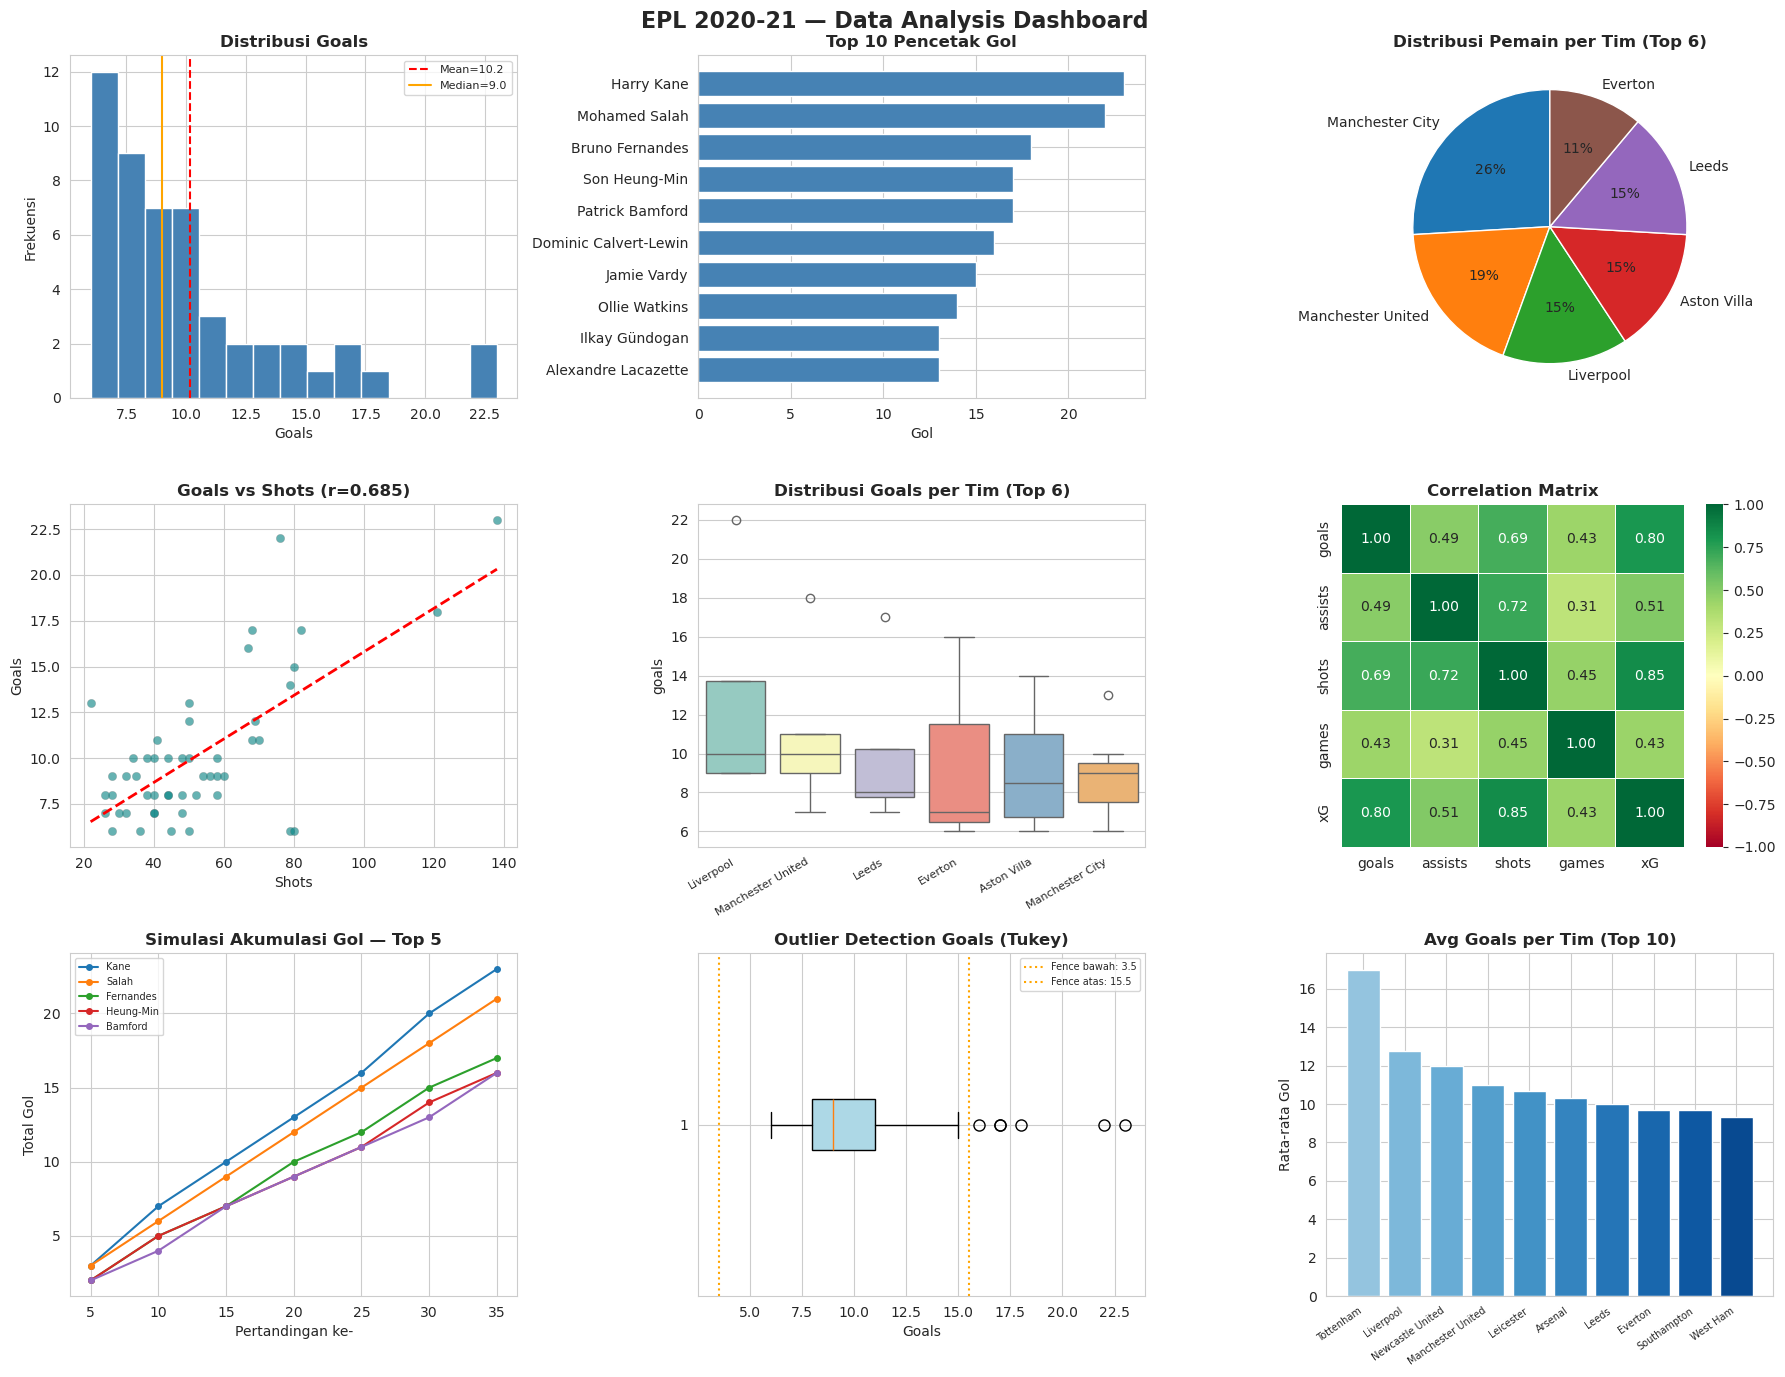

✅ Dashboard tersimpan: plot_dashboard_epl.png


In [11]:
# === STEP 5: Comprehensive Visualization Dashboard ===
print('='*50)
print('STEP 5: Dashboard Visualisasi')
print('='*50)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('EPL 2020-21 — Data Analysis Dashboard', fontsize=16, fontweight='bold', y=0.98)

# --- Plot 1: Histogram Goals ---
ax1 = fig.add_subplot(3, 3, 1)
df['goals'].hist(bins=15, ax=ax1, color='steelblue', edgecolor='white')
ax1.axvline(df['goals'].mean(),   color='red',    linestyle='--', label=f'Mean={df["goals"].mean():.1f}')
ax1.axvline(df['goals'].median(), color='orange', linestyle='-',  label=f'Median={df["goals"].median():.1f}')
ax1.set_title('Distribusi Goals', fontweight='bold')
ax1.set_xlabel('Goals'); ax1.set_ylabel('Frekuensi')
ax1.legend(fontsize=8)

# --- Plot 2: Bar Chart Top 10 Scorer ---
ax2 = fig.add_subplot(3, 3, 2)
top10 = df.nlargest(10, 'goals')
ax2.barh(top10['player_name'], top10['goals'], color='steelblue')
ax2.set_title('Top 10 Pencetak Gol', fontweight='bold')
ax2.set_xlabel('Gol')
ax2.invert_yaxis()

# --- Plot 3: Pie chart per tim ---
ax3 = fig.add_subplot(3, 3, 3)
top_teams = df['team_title'].value_counts().head(6)
ax3.pie(top_teams.values, labels=top_teams.index, autopct='%1.0f%%', startangle=90)
ax3.set_title('Distribusi Pemain per Tim (Top 6)', fontweight='bold')

# --- Plot 4: Scatter Goals vs Shots ---
ax4 = fig.add_subplot(3, 3, 4)
ax4.scatter(df['shots'], df['goals'], alpha=0.6, color='teal', edgecolors='gray', linewidth=0.3)
z = np.polyfit(df['shots'], df['goals'], 1)
p = np.poly1d(z)
ax4.plot(sorted(df['shots']), p(sorted(df['shots'])), 'r--', linewidth=2)
corr_gs = df['goals'].corr(df['shots'])
ax4.set_title(f'Goals vs Shots (r={corr_gs:.3f})', fontweight='bold')
ax4.set_xlabel('Shots'); ax4.set_ylabel('Goals')

# --- Plot 5: Boxplot Goals per Tim (Top 6) ---
ax5 = fig.add_subplot(3, 3, 5)
top6_teams = df['team_title'].value_counts().head(6).index
df_top6 = df[df['team_title'].isin(top6_teams)]
sns.boxplot(x='team_title', y='goals', data=df_top6, ax=ax5, palette='Set3')
ax5.set_title('Distribusi Goals per Tim (Top 6)', fontweight='bold')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax5.set_xlabel('')

# --- Plot 6: Heatmap Correlation ---
ax6 = fig.add_subplot(3, 3, 6)
corr = df[['goals','assists','shots','games','xG']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax6, square=True, linewidths=0.5)
ax6.set_title('Correlation Matrix', fontweight='bold')

# --- Plot 7: Line chart akumulasi gol ---
ax7 = fig.add_subplot(3, 3, 7)
top5 = df.nlargest(5, 'goals')
match_pts = np.arange(5, 40, 5)
for _, row in top5.iterrows():
    sim = np.clip(np.round((match_pts/row['games'])*row['goals']), 0, row['goals'])
    ax7.plot(match_pts, sim, marker='o', markersize=4, label=row['player_name'].split()[-1])
ax7.set_title('Simulasi Akumulasi Gol — Top 5', fontweight='bold')
ax7.set_xlabel('Pertandingan ke-'); ax7.set_ylabel('Total Gol')
ax7.legend(fontsize=7)

# --- Plot 8: Outlier Detection (Boxplot dengan outlier ditandai) ---
ax8 = fig.add_subplot(3, 3, 8)
ax8.boxplot(df['goals'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            flierprops=dict(marker='o', color='red', markersize=8))
ax8.axvline(q1 - 1.5*iqr, color='orange', linestyle=':', label=f'Fence bawah: {q1-1.5*iqr:.1f}')
ax8.axvline(q3 + 1.5*iqr, color='orange', linestyle=':', label=f'Fence atas: {q3+1.5*iqr:.1f}')
ax8.set_title('Outlier Detection Goals (Tukey)', fontweight='bold')
ax8.set_xlabel('Goals')
ax8.legend(fontsize=7)

# --- Plot 9: Rata-rata gol per tim (grouped bar) ---
ax9 = fig.add_subplot(3, 3, 9)
avg_goals = df.groupby('team_title')['goals'].mean().sort_values(ascending=False).head(10)
bars = ax9.bar(range(len(avg_goals)), avg_goals.values,
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(avg_goals))))
ax9.set_xticks(range(len(avg_goals)))
ax9.set_xticklabels(avg_goals.index, rotation=35, ha='right', fontsize=7)
ax9.set_title('Avg Goals per Tim (Top 10)', fontweight='bold')
ax9.set_ylabel('Rata-rata Gol')

plt.tight_layout()
plt.savefig('plot_dashboard_epl.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Dashboard tersimpan: plot_dashboard_epl.png')

In [12]:
# === STEP 6: ANOVA Kesimpulan Final ===
print('='*60)
print('STEP 6: ANOVA — Apakah tim berpengaruh terhadap gol?')
print('='*60)

grouped_epl = df.groupby('team_title')['goals']
groups_list = [g.values for _, g in grouped_epl if len(g) >= 2]
f_epl, p_epl = stats.f_oneway(*groups_list)

print(f'F-Score : {f_epl:.4f}')
print(f'P-Value : {p_epl:.4e}')
print()
print('INTERPRETASI:')
if p_epl < 0.001:
    level = 'SANGAT KUAT (p < 0.001) ⭐⭐⭐'
elif p_epl < 0.01:
    level = 'KUAT (p < 0.01) ⭐⭐'
elif p_epl < 0.05:
    level = 'MODERAT (p < 0.05) ⭐'
else:
    level = 'TIDAK SIGNIFIKAN (p > 0.05) ❌'

print(f'  Bukti statistik: {level}')
print(f'  Tim asal pemain {"berpengaruh" if p_epl < 0.05 else "TIDAK berpengaruh"} terhadap rata-rata gol yang dicetak.')

STEP 6: ANOVA — Apakah tim berpengaruh terhadap gol?
F-Score : 1.3500
P-Value : 2.3254e-01

INTERPRETASI:
  Bukti statistik: TIDAK SIGNIFIKAN (p > 0.05) ❌
  Tim asal pemain TIDAK berpengaruh terhadap rata-rata gol yang dicetak.


---
## 3. Rangkuman Lengkap Seluruh Materi

### 📌 Data Analysis Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│                    DATA ANALYSIS PIPELINE                       │
│                                                                  │
│  1. LOAD DATA          pd.read_csv()                           │
│         ↓                                                        │
│  2. INSPECT            .head() .tail() .dtypes .shape           │
│         ↓                                                        │
│  3. STATISTICAL SUMMARY .describe() .mean() .median() .mode()  │
│         ↓                                                        │
│  4. DISTRIBUTION       .std() .var() .quantile() .range()      │
│         ↓                                                        │
│  5. OUTLIER DETECTION  3-Sigma Rule / Tukey's Fences           │
│         ↓                                                        │
│  6. VISUALIZATION      Histogram, Scatter, Regplot, Boxplot    │
│         ↓                                                        │
│  7. CORRELATION        .corr() / stats.pearsonr()               │
│         ↓                                                        │
│  8. GROUPING           .groupby() → Pivot → Heatmap            │
│         ↓                                                        │
│  9. ANOVA              stats.f_oneway()                         │
│         ↓                                                        │
│ 10. INSIGHT & CONCLUSION                                        │
└─────────────────────────────────────────────────────────────────┘
```

### 📋 Tabel Fungsi Utama

| Kategori | Fungsi | Keterangan |
|---|---|---|
| Load | `pd.read_csv()` | Import CSV |
| Inspect | `.head()`, `.tail()`, `.dtypes` | Overview data |
| Summary | `.describe(include='all')` | Statistik dasar |
| Mean | `.mean()` | Rata-rata |
| Median | `.median()` | Nilai tengah |
| Mode | `.mode()` | Nilai terbanyak |
| Quantile | `.quantile(q)` | Persentil ke-q |
| Std Dev | `.std()` | Standar deviasi |
| Variance | `.var()` | Varians |
| Frequency | `.value_counts()` | Frekuensi kategori |
| Sort | `.sort_values()` | Urutkan data |
| Groupby | `.groupby().mean()` | Statistik per grup |
| Pivot | `.pivot()` | Tabel silang |
| Correlation | `.corr()` | Matriks korelasi Pearson |
| Pearson+p | `stats.pearsonr()` | Koefisien + p-value |
| ANOVA | `stats.f_oneway()` | F-Score + p-value |
| Pie Chart | `plt.pie()` | Proporsi kategori |
| Bar Chart | `plt.bar()` | Perbandingan kategori |
| Line Graph | `plt.plot()` | Tren waktu |
| Scatter | `plt.scatter()` | Hubungan 2 variabel |
| Histogram | `df.hist()` | Distribusi frekuensi |
| Regplot | `sns.regplot()` | Scatter + regresi |
| Boxplot | `sns.boxplot()` | Distribusi per kategori |
| Heatmap | `sns.heatmap()` | Matriks warna |

---
> 🎓 **Selesai!** Semua topik dari Pertemuan 3 (Data Analysis) telah dieksperimentasikan secara hands-on.